<div style="background: linear-gradient(135deg, #0F3D6E 0%, #2176AE 100%); padding: 40px 36px 32px 36px; border-radius: 10px; margin-bottom: 8px;">
  <p style="color: #C8DEF5; font-size: 13px; margin: 0 0 6px 0; letter-spacing: 2px;">CURSO 8 · MÓDULO 1 · CLASE 1</p>
  <h1 style="color: white; font-size: 36px; margin: 0 0 10px 0; font-weight: 700;">Ejercicios: Álgebra Lineal para Modelos Estadísticos</h1>
  <p style="color: #C8DEF5; font-size: 16px; margin: 0 0 24px 0; font-style: italic;">Práctica guiada para afianzar los fundamentos de OLS</p>
  <hr style="border-color: #5BA4CF; margin: 0 0 20px 0;">
  <p style="color: #EAF2FB; font-size: 13px; margin: 0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Nivel:</strong> Avanzado &nbsp;·&nbsp; <strong>Formato:</strong> Ejercicios con solución oculta</p>
</div>

## ¿Cómo usar este notebook?

Cada ejercicio tiene tres partes:

| Parte | Descripción |
|-------|-------------|
| 📋 **Enunciado** | Qué tenés que resolver |
| 🧩 **Tu código** | Celda vacía para que escribas la solución |
| ✅ **Solución** | Celda oculta — ejecutala solo después de intentarlo |

> **Regla de oro:** intentá resolver cada ejercicio antes de ver la solución. El error es parte del aprendizaje.

**Dificultad progresiva:**
- 🟢 Básico — operaciones directas
- 🟡 Intermedio — combinar conceptos
- 🔴 Avanzado — razonar + implementar

In [1]:
# Setup — ejecutar primero
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
SEED = 42
np.random.seed(SEED)

print('✅ Setup listo — a practicar!')

✅ Setup listo — a practicar!


---
## 🟢 BLOQUE 1 — Operaciones Matriciales Básicas

Fundamentos que aparecen en cada modelo. Tienen que salir automáticos.

### Ejercicio 1.1 — Verificar propiedades de la transpuesta

**Enunciado:**

Dadas las matrices A (3×4) y B (4×2):
1. Calcular el producto AB
2. Verificar que **(AB)ᵀ = BᵀAᵀ** — propiedad crítica en la derivación de OLS
3. Verificar que **(Aᵀ)ᵀ = A**
4. Imprimir los shapes de A, B, AB, (AB)ᵀ y comentar qué significa cada uno

In [2]:
# Matrices dadas
A = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
], dtype=float)

B = np.array([
    [2, 1],
    [0, 3],
    [1, 2],
    [4, 0]
], dtype=float)

# --- Tu código aquí ---


In [3]:
# ✅ SOLUCIÓN — intentá primero arriba

AB = A @ B
print(f'Shape A:     {A.shape}   → 3 filas, 4 columnas')
print(f'Shape B:     {B.shape}   → 4 filas, 2 columnas')
print(f'Shape AB:    {AB.shape}  → 3 filas, 2 columnas  (m×k · k×n = m×n)')
print(f'Shape (AB)ᵀ: {AB.T.shape} → 2 filas, 3 columnas')

print(f'\nAB =\n{AB}')

# Propiedad 1: (AB)ᵀ = BᵀAᵀ
lhs = (A @ B).T
rhs = B.T @ A.T
print(f'\n(AB)ᵀ == BᵀAᵀ → {np.allclose(lhs, rhs)}  ✓')

# Propiedad 2: (Aᵀ)ᵀ = A
print(f'(Aᵀ)ᵀ == A   → {np.allclose(A.T.T, A)}  ✓')

print('\n💡 Por qué importa: al derivar ∂(SSE)/∂β = ∂/∂β[βᵀXᵀXβ - 2βᵀXᵀy]')
print('   usamos (AB)ᵀ = BᵀAᵀ en cada paso del desarrollo.')

Shape A:     (3, 4)   → 3 filas, 4 columnas
Shape B:     (4, 2)   → 4 filas, 2 columnas
Shape AB:    (3, 2)  → 3 filas, 2 columnas  (m×k · k×n = m×n)
Shape (AB)ᵀ: (2, 3) → 2 filas, 3 columnas

AB =
[[21. 13.]
 [49. 37.]
 [77. 61.]]

(AB)ᵀ == BᵀAᵀ → True  ✓
(Aᵀ)ᵀ == A   → True  ✓

💡 Por qué importa: al derivar ∂(SSE)/∂β = ∂/∂β[βᵀXᵀXβ - 2βᵀXᵀy]
   usamos (AB)ᵀ = BᵀAᵀ en cada paso del desarrollo.


### Ejercicio 1.2 — Traza y sus propiedades

**Enunciado:**

Dada la matriz cuadrada C:
1. Calcular tr(C)
2. Generar una matriz aleatoria D del mismo tamaño y verificar la **propiedad cíclica: tr(CD) = tr(DC)**
3. ¿Cuánto es tr(Iₙ)? Verificarlo para n = 5
4. **Pregunta de razonamiento:** si H es la hat matrix de un modelo con 4 parámetros sobre 100 observaciones, ¿cuánto vale tr(H) sin calcularlo?

In [4]:
np.random.seed(SEED)

C = np.array([
    [4, 1, 2],
    [0, 3, 5],
    [7, 2, 1]
], dtype=float)

# --- Tu código aquí ---


In [5]:
# ✅ SOLUCIÓN

np.random.seed(SEED)
C = np.array([[4,1,2],[0,3,5],[7,2,1]], dtype=float)
D = np.random.randn(3, 3)

# 1. Traza
print(f'Diagonal de C: {np.diag(C)}')
print(f'tr(C) = {np.trace(C)}   (suma de la diagonal: 4 + 3 + 1)')

# 2. Propiedad cíclica
trCD = np.trace(C @ D)
trDC = np.trace(D @ C)
print(f'\ntr(CD) = {trCD:.6f}')
print(f'tr(DC) = {trDC:.6f}')
print(f'tr(CD) == tr(DC) → {np.isclose(trCD, trDC)}  ✓')

# 3. tr(Iₙ)
n = 5
print(f'\ntr(I₅) = {np.trace(np.eye(n))}  (siempre = n)  ✓')

# 4. Razonamiento
print(f'\n💡 tr(H) = p = 4')
print('   La traza de la hat matrix siempre iguala al número de')
print('   columnas de X (grados de libertad del modelo).')
print('   No necesitamos construir H (100×100) para saberlo.')

Diagonal de C: [4. 3. 1.]
tr(C) = 8.0   (suma de la diagonal: 4 + 3 + 1)

tr(CD) = 13.399097
tr(DC) = 13.399097
tr(CD) == tr(DC) → True  ✓

tr(I₅) = 5.0  (siempre = n)  ✓

💡 tr(H) = p = 4
   La traza de la hat matrix siempre iguala al número de
   columnas de X (grados de libertad del modelo).
   No necesitamos construir H (100×100) para saberlo.


### Ejercicio 1.3 — Construir la matriz de diseño X correctamente

**Enunciado:**

Tienes los siguientes datos de 6 empleados. Tu tarea:
1. Construir la matriz de diseño X con intercepto (columna de unos)
2. Verificar su shape: debe ser (6, 3)
3. Calcular XᵀX e imprimir su forma
4. ¿Es XᵀX simétrica? Verificarlo con código
5. **Trampa:** ¿qué pasa si olvidás la columna de unos?

In [6]:
# Datos: antigüedad (años) y capacitaciones completadas → salario (USD/mes)
antiguedad    = np.array([2, 5, 8, 3, 10, 1], dtype=float)
capacitaciones = np.array([3, 7, 6, 4, 9, 2], dtype=float)
salario       = np.array([2800, 4200, 5100, 3100, 6000, 2500], dtype=float)

# --- Tu código aquí ---


In [7]:
# ✅ SOLUCIÓN

antiguedad    = np.array([2, 5, 8, 3, 10, 1], dtype=float)
capacitaciones = np.array([3, 7, 6, 4, 9, 2], dtype=float)
salario        = np.array([2800, 4200, 5100, 3100, 6000, 2500], dtype=float)

n = len(salario)

# 1. Matriz de diseño CON intercepto
X = np.column_stack([np.ones(n), antiguedad, capacitaciones])
print(f'Shape de X: {X.shape}  → {n} obs × 3 columnas [1 | antigüedad | capacitaciones]')
print('\nX ='); print(X)

# 2. XᵀX
XtX = X.T @ X
print(f'\nXᵀX (3×3) =\n{XtX}')

# 3. ¿Simétrica?
print(f'\nXᵀX simétrica → {np.allclose(XtX, XtX.T)}  ✓')
print('  Siempre es simétrica: (XᵀX)ᵀ = Xᵀ(Xᵀ)ᵀ = XᵀX')

# 4. Trampa: sin columna de unos
X_sin_ones = np.column_stack([antiguedad, capacitaciones])
beta_con    = np.linalg.lstsq(X, salario, rcond=None)[0]
beta_sin    = np.linalg.lstsq(X_sin_ones, salario, rcond=None)[0]

print(f'\n⚠  Comparación de estimaciones:')
print(f'  Con intercepto:    β = {beta_con.round(1)}')
print(f'  Sin intercepto:    β = {beta_sin.round(1)}')
print('  Sin intercepto el modelo se fuerza a pasar por el origen → β₁ y β₂ se distorsionan.')

Shape de X: (6, 3)  → 6 obs × 3 columnas [1 | antigüedad | capacitaciones]

X =
[[ 1.  2.  3.]
 [ 1.  5.  7.]
 [ 1.  8.  6.]
 [ 1.  3.  4.]
 [ 1. 10.  9.]
 [ 1.  1.  2.]]

XᵀX (3×3) =
[[  6.  29.  31.]
 [ 29. 203. 193.]
 [ 31. 193. 195.]]

XᵀX simétrica → True  ✓
  Siempre es simétrica: (XᵀX)ᵀ = Xᵀ(Xᵀ)ᵀ = XᵀX

⚠  Comparación de estimaciones:
  Con intercepto:    β = [1905.7  337.2   80.2]
  Sin intercepto:    β = [ 69.6 648. ]
  Sin intercepto el modelo se fuerza a pasar por el origen → β₁ y β₂ se distorsionan.


---
## 🟡 BLOQUE 2 — Rango, Condición y Multicolinealidad

### Ejercicio 2.1 — Detectar multicolinealidad antes de modelar

**Enunciado:**

Un analista junior armó la siguiente matriz de diseño con 5 variables. Sospechás que hay multicolinealidad. Tu tarea:
1. Calcular `rank(X)` y compararlo con el número de columnas
2. Calcular `det(XᵀX)` y `cond(XᵀX)`
3. Identificar **cuál o cuáles columnas** generan el problema
4. Proponer una solución (sin eliminar datos)
5. Verificar que después de tu corrección `rank(X_corregida) == p`

In [8]:
np.random.seed(SEED)
n = 50

x1 = np.random.uniform(1, 10, n)    # feature principal
x2 = np.random.uniform(0, 5, n)     # otra feature
x3 = 3 * x1                         # ← columna problemática
x4 = np.random.randn(n)             # ruido
x5 = x1 + x2                        # ← otra combinación lineal

X_problema = np.column_stack([np.ones(n), x1, x2, x3, x4, x5])

# --- Tu código aquí ---


In [9]:
# ✅ SOLUCIÓN

np.random.seed(SEED)
n = 50
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(0, 5, n)
x3 = 3 * x1
x4 = np.random.randn(n)
x5 = x1 + x2
X_problema = np.column_stack([np.ones(n), x1, x2, x3, x4, x5])

p_total = X_problema.shape[1]
rango   = np.linalg.matrix_rank(X_problema)
XtX_p   = X_problema.T @ X_problema

print('─── Diagnóstico ────────────────────────────────')
print(f'  Columnas:    {p_total}')
print(f'  rank(X):     {rango}   ← rango deficiente!')
print(f'  det(XᵀX):    {np.linalg.det(XtX_p):.2e}  ≈ 0')
print(f'  cond(XᵀX):   {np.linalg.cond(XtX_p):.2e}  ← peligroso')

print('\n─── Problema identificado ───────────────────────')
print('  Col 4 (x3) = 3 × Col 2 (x1)   → combinación lineal exacta')
print('  Col 6 (x5) = Col 2 + Col 3     → otra combinación lineal')
print('  Hay 2 columnas linealmente dependientes → rank = 4, no 6')

# Solución: eliminar las columnas dependientes
X_corregida = np.column_stack([np.ones(n), x1, x2, x4])
rango_c     = np.linalg.matrix_rank(X_corregida)
cond_c      = np.linalg.cond(X_corregida.T @ X_corregida)

print('\n─── Después de la corrección ────────────────────')
print(f'  rank(X_corregida): {rango_c} == p = {X_corregida.shape[1]}  ✓')
print(f'  cond(XᵀX):         {cond_c:.1f}  ✓  estable')
print('\n  Alternativa: estandarizar + usar Ridge si no podés eliminar columnas.')

─── Diagnóstico ────────────────────────────────
  Columnas:    6
  rank(X):     4   ← rango deficiente!
  det(XᵀX):    -2.43e-16  ≈ 0
  cond(XᵀX):   8.29e+16  ← peligroso

─── Problema identificado ───────────────────────
  Col 4 (x3) = 3 × Col 2 (x1)   → combinación lineal exacta
  Col 6 (x5) = Col 2 + Col 3     → otra combinación lineal
  Hay 2 columnas linealmente dependientes → rank = 4, no 6

─── Después de la corrección ────────────────────
  rank(X_corregida): 4 == p = 4  ✓
  cond(XᵀX):         323.8  ✓  estable

  Alternativa: estandarizar + usar Ridge si no podés eliminar columnas.


### Ejercicio 2.2 — El impacto del número de condición en β̂

**Enunciado:**

Vas a demostrar **empíricamente** que un número de condición alto hace que β̂ sea inestable. Tu tarea:
1. Generar un dataset simple con β verdadero = [2.0, 5.0]
2. Crear dos versiones de X: una estandarizada y otra sin estandarizar (con variables en escalas muy distintas)
3. Calcular β̂ en ambos casos
4. Agregar un pequeño ruido a X (simular error de medición) y recalcular β̂
5. Comparar cuánto cambia β̂ en cada caso y explicar por qué

In [10]:
np.random.seed(SEED)
n = 100

# Feature en dos escalas muy distintas
x_pequeña = np.random.uniform(0, 1, n)           # escala 0–1
x_grande  = x_pequeña * 100_000                  # misma feature, escala 0–100k

beta_verdadero = np.array([2.0, 5.0])
y = 2.0 + 5.0 * x_pequeña + np.random.normal(0, 0.1, n)

# --- Tu código aquí ---


In [11]:
# ✅ SOLUCIÓN

np.random.seed(SEED)
n = 100
x_pequeña = np.random.uniform(0, 1, n)
x_grande  = x_pequeña * 100_000
beta_verdadero = np.array([2.0, 5.0])
y = 2.0 + 5.0 * x_pequeña + np.random.normal(0, 0.1, n)

# Dos versiones de X
X_ok  = np.column_stack([np.ones(n), x_pequeña])  # escala normal
X_mal = np.column_stack([np.ones(n), x_grande])   # escala enorme

cond_ok  = np.linalg.cond(X_ok.T  @ X_ok)
cond_mal = np.linalg.cond(X_mal.T @ X_mal)

beta_ok,  *_ = np.linalg.lstsq(X_ok,  y, rcond=None)
beta_mal, *_ = np.linalg.lstsq(X_mal, y, rcond=None)

print('Condición sin y con escala grande:')
print(f'  cond(XᵀX) escala normal:  {cond_ok:.1f}')
print(f'  cond(XᵀX) escala grande:  {cond_mal:.2e}')

# Agregar ruido pequeño a X
ruido = np.random.normal(0, 1e-6, n)  # perturbación mínima
X_ok_r  = np.column_stack([np.ones(n), x_pequeña + ruido])
X_mal_r = np.column_stack([np.ones(n), x_grande  + ruido])

beta_ok_r,  *_ = np.linalg.lstsq(X_ok_r,  y, rcond=None)
beta_mal_r, *_ = np.linalg.lstsq(X_mal_r, y, rcond=None)

print('\nCambio en β̂ al agregar ruido mínimo a X:')
print(f'  Escala normal: Δβ = {np.abs(beta_ok_r - beta_ok).max():.6f}   ← estable')
print(f'  Escala grande: Δβ = {np.abs(beta_mal_r - beta_mal).max():.6f}  ← inestable')

print('\n💡 Conclusión:')
print('  Cond alto → pequeños cambios en X generan grandes cambios en β̂.')
print('  Estandarizar reduce el cond y hace el modelo robusto a errores de medición.')

Condición sin y con escala grande:
  cond(XᵀX) escala normal:  17.5
  cond(XᵀX) escala grande:  1.09e+10

Cambio en β̂ al agregar ruido mínimo a X:
  Escala normal: Δβ = 0.000000   ← estable
  Escala grande: Δβ = 0.000000  ← inestable

💡 Conclusión:
  Cond alto → pequeños cambios en X generan grandes cambios en β̂.
  Estandarizar reduce el cond y hace el modelo robusto a errores de medición.


---
## 🟡 BLOQUE 3 — La Ecuación Normal y β̂

### Ejercicio 3.1 — Calcular β̂ paso a paso (sin usar lstsq)

**Enunciado:**

Usando el dataset de empleados del ejercicio 1.3, implementá la ecuación normal **paso a paso**, mostrando cada operación intermedia:

$$\hat{\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Además:
1. Verificar que **Xᵀe ≈ 0** (condición de optimalidad)
2. Calcular SSE, SST y R²
3. Interpretar cada coeficiente en palabras simples

In [12]:
# Datos del ejercicio 1.3
antiguedad     = np.array([2, 5, 8, 3, 10, 1], dtype=float)
capacitaciones = np.array([3, 7, 6, 4,  9, 2], dtype=float)
salario        = np.array([2800, 4200, 5100, 3100, 6000, 2500], dtype=float)

n  = len(salario)
X  = np.column_stack([np.ones(n), antiguedad, capacitaciones])
y  = salario

# --- Tu código aquí (implementar la ecuación normal paso a paso) ---


In [13]:
# ✅ SOLUCIÓN

antiguedad     = np.array([2, 5, 8, 3, 10, 1], dtype=float)
capacitaciones = np.array([3, 7, 6, 4,  9, 2], dtype=float)
salario        = np.array([2800, 4200, 5100, 3100, 6000, 2500], dtype=float)
n = len(salario)
X = np.column_stack([np.ones(n), antiguedad, capacitaciones])
y = salario

# Paso 1: XᵀX
XtX = X.T @ X
print('Paso 1 — XᵀX ='); print(XtX)

# Paso 2: (XᵀX)⁻¹
XtX_inv = np.linalg.inv(XtX)
print('\nPaso 2 — (XᵀX)⁻¹ ='); print(XtX_inv.round(6))

# Paso 3: Xᵀy
Xty = X.T @ y
print('\nPaso 3 — Xᵀy =', Xty)

# Paso 4: β̂
beta_hat = XtX_inv @ Xty
print(f'\nPaso 4 — β̂ = {beta_hat.round(2)}')
print(f'  β₀ (intercepto):     {beta_hat[0]:.2f} USD/mes (salario base)')
print(f'  β₁ (antigüedad):     {beta_hat[1]:.2f} USD/mes por año adicional')
print(f'  β₂ (capacitaciones): {beta_hat[2]:.2f} USD/mes por capacitación adicional')

# Verificar optimalidad: Xᵀe ≈ 0
y_hat = X @ beta_hat
e = y - y_hat
print(f'\nXᵀe = {(X.T @ e).round(6)}  ← debe ser ≈ 0  ✓')

# Métricas
SSE = e @ e
SST = (y - y.mean()) @ (y - y.mean())
R2  = 1 - SSE / SST
print(f'\nSSE = {SSE:.2f}  |  SST = {SST:.2f}  |  R² = {R2:.4f}')
print(f'El modelo explica el {R2*100:.1f}% de la variación salarial.')

Paso 1 — XᵀX =
[[  6.  29.  31.]
 [ 29. 203. 193.]
 [ 31. 193. 195.]]

Paso 2 — (XᵀX)⁻¹ =
[[ 1.1967  0.168  -0.3566]
 [ 0.168   0.1071 -0.1327]
 [-0.3566 -0.1327  0.1931]]

Paso 3 — Xᵀy = [ 23700. 139200. 139800.]

Paso 4 — β̂ = [1905.74  337.19   80.23]
  β₀ (intercepto):     1905.74 USD/mes (salario base)
  β₁ (antigüedad):     337.19 USD/mes por año adicional
  β₂ (capacitaciones): 80.23 USD/mes por capacitación adicional

Xᵀe = [-0. -0. -0.]  ← debe ser ≈ 0  ✓

SSE = 31290.98  |  SST = 9735000.00  |  R² = 0.9968
El modelo explica el 99.7% de la variación salarial.


### Ejercicio 3.2 — Comparar tres métodos de estimación

**Enunciado:**

Existen tres formas de calcular β̂ en NumPy. Tu tarea:
1. Implementar los tres métodos con el mismo dataset (generado abajo)
2. Verificar que los tres dan el mismo resultado
3. Medir el tiempo de ejecución de cada uno con `%%timeit` o `time.perf_counter`
4. Explicar en qué situación usarías cada uno

**Métodos:**
- Método A: `np.linalg.inv(XtX) @ Xty`
- Método B: `np.linalg.lstsq(X, y)`
- Método C: `np.linalg.solve(XtX, Xty)` — más estable que inv()

In [14]:
np.random.seed(SEED)
n, p = 500, 6

beta_real = np.array([3.0, 1.5, -2.0, 0.8, 4.2, -1.1])
X_raw = np.random.randn(n, p - 1)   # 5 features
scaler_ej = StandardScaler().fit(X_raw)
X_sc = scaler_ej.transform(X_raw)
X_data = np.column_stack([np.ones(n), X_sc])
y_data = X_data @ beta_real + np.random.normal(0, 0.5, n)

# --- Tu código aquí ---


In [15]:
# ✅ SOLUCIÓN
import time

np.random.seed(SEED)
n, p = 500, 6
beta_real = np.array([3.0, 1.5, -2.0, 0.8, 4.2, -1.1])
X_raw = np.random.randn(n, p - 1)
X_sc  = StandardScaler().fit_transform(X_raw)
X_data = np.column_stack([np.ones(n), X_sc])
y_data = X_data @ beta_real + np.random.normal(0, 0.5, n)

XtX_d = X_data.T @ X_data
Xty_d = X_data.T @ y_data

# Los tres métodos
results = {}

t0 = time.perf_counter()
for _ in range(1000):
    beta_A = np.linalg.inv(XtX_d) @ Xty_d
results['A — inv()'] = (beta_A, (time.perf_counter()-t0)/1000*1e6)

t0 = time.perf_counter()
for _ in range(1000):
    beta_B, *_ = np.linalg.lstsq(X_data, y_data, rcond=None)
results['B — lstsq()'] = (beta_B, (time.perf_counter()-t0)/1000*1e6)

t0 = time.perf_counter()
for _ in range(1000):
    beta_C = np.linalg.solve(XtX_d, Xty_d)
results['C — solve()'] = (beta_C, (time.perf_counter()-t0)/1000*1e6)

print('Verificación — todos dan el mismo β̂:')
print(f'  A ≈ B: {np.allclose(beta_A, beta_B)}')
print(f'  A ≈ C: {np.allclose(beta_A, beta_C)}')
print(f'\nβ̂ estimado: {beta_A.round(4)}')
print(f'β  real:     {beta_real}')

print('\nTiempos de ejecución (promedio 1000 runs):')
for nombre, (_, t) in results.items():
    print(f'  {nombre:20s}: {t:.1f} μs')

print('\n💡 Cuándo usar cada uno:')
print('  A — inv():    Nunca en producción. Útil solo para mostrar la fórmula.')
print('  B — lstsq():  Siempre en producción. Maneja rango deficiente.')
print('  C — solve():  Más estable que inv(). Bueno cuando XᵀX es cuadrada y bien condicionada.')

Verificación — todos dan el mismo β̂:
  A ≈ B: True
  A ≈ C: True

β̂ estimado: [ 3.0116  1.5054 -2.0048  0.78    4.1766 -1.0908]
β  real:     [ 3.   1.5 -2.   0.8  4.2 -1.1]

Tiempos de ejecución (promedio 1000 runs):
  A — inv()           : 2.7 μs
  B — lstsq()         : 28.6 μs
  C — solve()         : 2.4 μs

💡 Cuándo usar cada uno:
  A — inv():    Nunca en producción. Útil solo para mostrar la fórmula.
  B — lstsq():  Siempre en producción. Maneja rango deficiente.
  C — solve():  Más estable que inv(). Bueno cuando XᵀX es cuadrada y bien condicionada.


---
## 🟡 BLOQUE 4 — Matrices Especiales en Regresión

### Ejercicio 4.1 — Construir y verificar la hat matrix H

**Enunciado:**

La **hat matrix** H = X(XᵀX)⁻¹Xᵀ es central en diagnósticos de regresión.

Usando el dataset generado abajo:
1. Construir H desde cero
2. Verificar las 3 propiedades: idempotente, simétrica, tr(H) = p
3. Verificar que ŷ = Hy
4. Verificar que I − H también es idempotente
5. **Bonus:** graficar los valores de la diagonal de H (leverage) e identificar los puntos de alto leverage

In [16]:
np.random.seed(SEED)
n_h = 80
X_h_raw = np.random.randn(n_h, 3)
X_h = np.column_stack([np.ones(n_h), X_h_raw])
y_h = X_h @ np.array([1.0, 2.0, -1.0, 0.5]) + np.random.normal(0, 0.5, n_h)

# --- Tu código aquí ---


H shape: (80, 80)

Propiedades de H:
  1. Idempotente (H² = H):   True
  2. Simétrica (H = Hᵀ):     True
  3. tr(H) = p:              True  (tr=4.0000, p=4)
  4. ŷ = Hy:                 True
  5. (I-H)² = I-H:           True


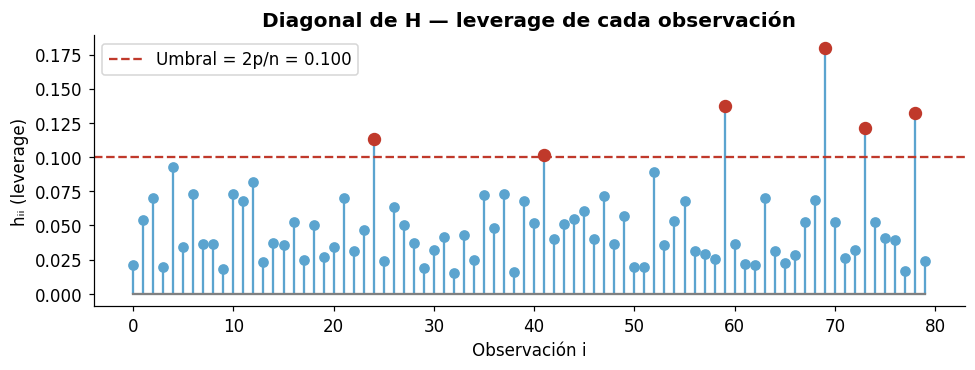


Puntos con alto leverage: 6 de 80
Alta influencia = puntos que pueden torcer la recta de regresión.


In [17]:
# ✅ SOLUCIÓN

np.random.seed(SEED)
n_h = 80
X_h_raw = np.random.randn(n_h, 3)
X_h     = np.column_stack([np.ones(n_h), X_h_raw])
y_h     = X_h @ np.array([1.0, 2.0, -1.0, 0.5]) + np.random.normal(0, 0.5, n_h)

# Construir H
XtX_h     = X_h.T @ X_h
XtX_h_inv = np.linalg.inv(XtX_h)
H = X_h @ XtX_h_inv @ X_h.T

print(f'H shape: {H.shape}')

# Verificar propiedades
p_h = X_h.shape[1]
print(f'\nPropiedades de H:')
print(f'  1. Idempotente (H² = H):   {np.allclose(H @ H, H, atol=1e-10)}')
print(f'  2. Simétrica (H = Hᵀ):     {np.allclose(H, H.T, atol=1e-10)}')
print(f'  3. tr(H) = p:              {np.isclose(np.trace(H), p_h, atol=1e-8)}  (tr={np.trace(H):.4f}, p={p_h})')

# ŷ = Hy
beta_h, *_ = np.linalg.lstsq(X_h, y_h, rcond=None)
y_hat_directo = X_h @ beta_h
y_hat_H       = H @ y_h
print(f'  4. ŷ = Hy:                 {np.allclose(y_hat_directo, y_hat_H, atol=1e-8)}')

# I-H idempotente
M_h = np.eye(n_h) - H
print(f'  5. (I-H)² = I-H:           {np.allclose(M_h @ M_h, M_h, atol=1e-8)}')

# Bonus: leverage
h_ii = np.diag(H)
umbral = 2 * p_h / n_h   # regla: hii > 2p/n = leverage alto
alto_leverage = np.where(h_ii > umbral)[0]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.stem(range(n_h), h_ii, linefmt='#5BA4CF', markerfmt='o', basefmt='gray')
ax.axhline(umbral, color='#C0392B', linestyle='--', lw=1.5,
           label=f'Umbral = 2p/n = {umbral:.3f}')
ax.scatter(alto_leverage, h_ii[alto_leverage], color='#C0392B', s=60, zorder=5)
ax.set_xlabel('Observación i')
ax.set_ylabel('hᵢᵢ (leverage)')
ax.set_title('Diagonal de H — leverage de cada observación', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nPuntos con alto leverage: {len(alto_leverage)} de {n_h}')
print('Alta influencia = puntos que pueden torcer la recta de regresión.')

### Ejercicio 4.2 — Matrices idempotentes y sus implicancias

**Enunciado:**

Una propiedad importante: si A es idempotente, entonces los eigenvalues de A solo pueden ser 0 ó 1.

1. Verificar esto empíricamente para H e I−H
2. ¿Qué relación hay entre los eigenvalues de H y tr(H)?
3. Construir una matriz idempotente 4×4 desde cero (sin usar H) y verificar la propiedad
4. **Pregunta:** ¿puede una matriz idempotente ser definida positiva? ¿Por qué?

In [18]:
# Usar H e I-H del ejercicio anterior
# H y M_h ya están definidos

# --- Tu código aquí ---


In [19]:
# ✅ SOLUCIÓN

# 1. Eigenvalues de H e I-H
eig_H  = np.linalg.eigvalsh(H)
eig_M  = np.linalg.eigvalsh(M_h)

# Redondear a 1 decimal para ver que son 0 o 1
unique_H = np.unique(eig_H.round(6))
unique_M = np.unique(eig_M.round(6))

print(f'Eigenvalues únicos de H (redondeados a 6 dec):')
print(f'  Mín = {eig_H.min():.6f},  Máx = {eig_H.max():.6f}')
print(f'  → Solo 0s y 1s  ✓')

# 2. Relación eigenvalues y traza
suma_eig_H = eig_H.sum()
print(f'\nΣ eigenvalues(H) = {suma_eig_H:.4f}')
print(f'tr(H)            = {np.trace(H):.4f}')
print(f'Iguales → {np.isclose(suma_eig_H, np.trace(H))}  ✓')
print(f'(La traza siempre = suma de eigenvalues — propiedad general de matrices)')

# 3. Construir una idempotente desde cero
# A = v vᵀ / (vᵀv) es idempotente para cualquier v ≠ 0
v = np.array([1.0, 2.0, 3.0, 4.0])
A_idem = np.outer(v, v) / (v @ v)

print(f'\nMatriz idempotente construida (A = vvᵀ/‖v‖²):')
print(f'  A² = A  → {np.allclose(A_idem @ A_idem, A_idem)}  ✓')
print(f'  tr(A)  = {np.trace(A_idem):.4f}  (rank 1 → tr = 1)')

# 4. ¿Idempotente puede ser definida positiva?
print(f'\n❓ ¿A_idem es definida positiva?')
eig_A = np.linalg.eigvalsh(A_idem)
print(f'   Eigenvalues: {eig_A.round(4)}')
print(f'   ¿Todos > 0? {np.all(eig_A > 0)}')
print('\n💡 Respuesta: NO (salvo la identidad).')
print('   Una idempotente tiene eigenvalues 0 y 1 → al menos un 0 → no es def. positiva.')
print('   Excepción: Iₙ (todos los eigenvalues = 1).')

Eigenvalues únicos de H (redondeados a 6 dec):
  Mín = -0.000000,  Máx = 1.000000
  → Solo 0s y 1s  ✓

Σ eigenvalues(H) = 4.0000
tr(H)            = 4.0000
Iguales → True  ✓
(La traza siempre = suma de eigenvalues — propiedad general de matrices)

Matriz idempotente construida (A = vvᵀ/‖v‖²):
  A² = A  → True  ✓
  tr(A)  = 1.0000  (rank 1 → tr = 1)

❓ ¿A_idem es definida positiva?
   Eigenvalues: [-0. -0.  0.  1.]
   ¿Todos > 0? False

💡 Respuesta: NO (salvo la identidad).
   Una idempotente tiene eigenvalues 0 y 1 → al menos un 0 → no es def. positiva.
   Excepción: Iₙ (todos los eigenvalues = 1).


---
## 🔴 BLOQUE 5 — Ejercicios Integradores

### Ejercicio 5.1 — Pipeline completo desde cero

**Enunciado:**

Vas a implementar un pipeline OLS completo para predecir el precio de venta de inmuebles, usando este dataset simulado.

**Requisitos (en orden):**
1. EDA: shape, estadísticas, 1 gráfico de correlaciones
2. Preprocesamiento: estandarizar + intercepto + split 75/25
3. Diagnóstico matricial: rank, cond — antes de modelar
4. Estimar β̂ con `lstsq`
5. Evaluar: R² train, R² test, RMSE, σ̂²
6. Verificar Xᵀe ≈ 0
7. Graficar: residuos vs ajustados
8. Interpretación: ¿cuál variable tiene más impacto? ¿el modelo generaliza bien?

In [20]:
# Dataset: precio de inmuebles
np.random.seed(7)
n_prop = 300

metros2    = np.random.uniform(40, 250, n_prop)
habitaciones = np.random.randint(1, 6, n_prop).astype(float)
antiguedad_p = np.random.uniform(0, 40, n_prop)
distancia_centro = np.random.uniform(0.5, 30, n_prop)   # km

# Precio real (USD k)
precio_prop = (80
               + 1.8  * metros2
               + 12   * habitaciones
               - 0.9  * antiguedad_p
               - 4.5  * distancia_centro
               + np.random.normal(0, 15, n_prop))

df_prop = pd.DataFrame({
    'metros2':          metros2,
    'habitaciones':     habitaciones,
    'antiguedad':       antiguedad_p,
    'distancia_centro': distancia_centro,
    'precio_usd_k':     precio_prop,
})

print('Dataset inmuebles:', df_prop.shape)
df_prop.head()

# --- Tu pipeline completo aquí ---


Dataset inmuebles: (300, 5)


,metros2,habitaciones,antiguedad,distancia_centro,precio_usd_k
0,56.024741,3.0,28.100095,24.884426,60.608843
1,203.782946,1.0,26.132764,15.091071,406.299677
2,132.065939,3.0,35.699326,19.243243,229.478728
3,191.927687,5.0,2.952441,2.434702,463.704414
4,245.377798,5.0,7.150616,15.734762,493.526747


─── EDA ─────────────────────────────────────────────
       metros2  habitaciones  antiguedad  distancia_centro  precio_usd_k
count    300.0         300.0       300.0             300.0         300.0
mean     143.1           3.0        19.6              14.6         290.9
std       61.2           1.4        11.6               8.3         116.1
min       40.3           1.0         0.0               0.6          50.0
25%       90.4           2.0         9.7               7.5         203.8
50%      140.1           3.0        19.1              14.1         287.4
75%      198.0           4.0        30.0              22.3         388.0
max      248.4           5.0        40.0              29.9         541.4


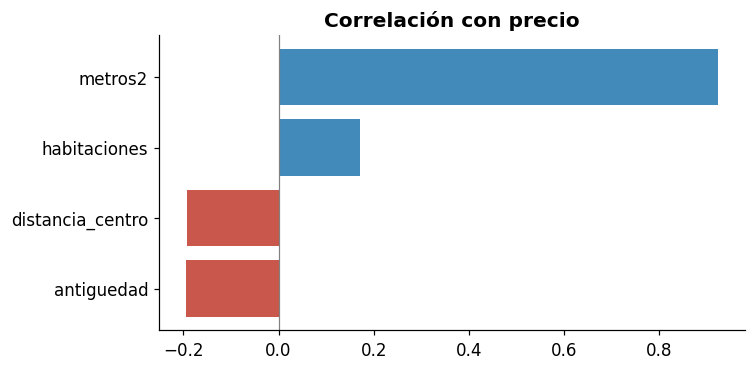


─── Diagnóstico ─────────────────────────────────────
rank(X) = 5 / 5  ✓
cond(XᵀX) = 1.6  ✓

─── Resultados ──────────────────────────────────────
R² train: 0.9830
R² test:  0.9837
RMSE test:14.31 USD k
σ̂²:       238.03

Xᵀe ≈ 0: True  ✓


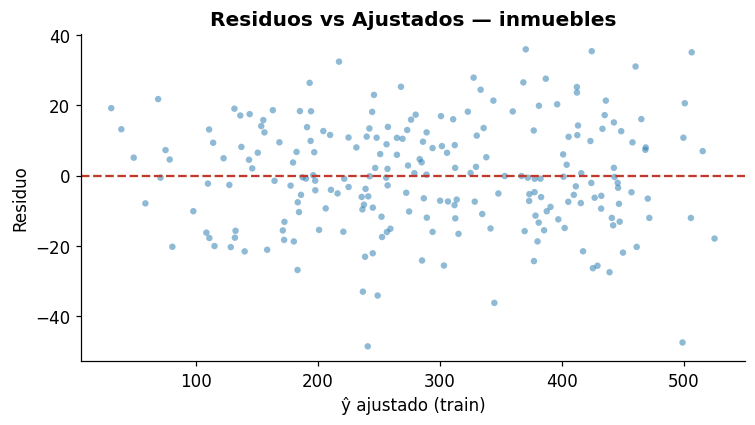


─── Interpretación ──────────────────────────────────
  intercepto          : +291.08 USD k por 1 SD
  metros2             : +111.01 USD k por 1 SD
  habitaciones        : +16.97 USD k por 1 SD
  antiguedad          : -9.30 USD k por 1 SD
  distancia_centro    : -36.29 USD k por 1 SD

  → metros2 y habitaciones suben el precio
  → antigüedad y distancia lo bajan (signos negativos)
  → R² train ≈ R² test → el modelo generaliza bien


In [21]:
# ✅ SOLUCIÓN

np.random.seed(7)
n_prop = 300
metros2         = np.random.uniform(40, 250, n_prop)
habitaciones    = np.random.randint(1, 6, n_prop).astype(float)
antiguedad_p    = np.random.uniform(0, 40, n_prop)
distancia_centro = np.random.uniform(0.5, 30, n_prop)
precio_prop = np.clip(
    80 + 1.8*metros2 + 12*habitaciones - 0.9*antiguedad_p - 4.5*distancia_centro
    + np.random.normal(0, 15, n_prop), 50, 700)
df_prop = pd.DataFrame({
    'metros2': metros2, 'habitaciones': habitaciones,
    'antiguedad': antiguedad_p, 'distancia_centro': distancia_centro,
    'precio_usd_k': precio_prop
})

# 1. EDA
print('─── EDA ─────────────────────────────────────────────')
print(df_prop.describe().round(1).to_string())
feats_prop = ['metros2','habitaciones','antiguedad','distancia_centro']
corr_prop  = df_prop.corr(numeric_only=True)['precio_usd_k'].drop('precio_usd_k').sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(corr_prop.index, corr_prop.values,
        color=['#C0392B' if c < 0 else '#2176AE' for c in corr_prop], alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Correlación con precio', fontweight='bold')
plt.tight_layout(); plt.show()

# 2. Preprocesamiento
X_prop_raw = df_prop[feats_prop].values
y_prop     = df_prop['precio_usd_k'].values
sc_prop    = StandardScaler().fit(X_prop_raw)
X_prop_sc  = sc_prop.transform(X_prop_raw)
X_prop     = np.column_stack([np.ones(n_prop), X_prop_sc])

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    X_prop, y_prop, test_size=0.25, random_state=SEED)

# 3. Diagnóstico matricial
XtX_p_ok = Xp_tr.T @ Xp_tr
print(f'\n─── Diagnóstico ─────────────────────────────────────')
print(f'rank(X) = {np.linalg.matrix_rank(Xp_tr)} / {Xp_tr.shape[1]}  ✓')
print(f'cond(XᵀX) = {np.linalg.cond(XtX_p_ok):.1f}  ✓')

# 4. Estimar β̂
beta_prop, *_ = np.linalg.lstsq(Xp_tr, yp_tr, rcond=None)

# 5. Evaluar
yp_hat_tr = Xp_tr @ beta_prop
yp_hat_te = Xp_te @ beta_prop
ep_tr     = yp_tr - yp_hat_tr
n_tr, p_prop = Xp_tr.shape
SSE_p = ep_tr @ ep_tr
SST_p = (yp_tr - yp_tr.mean()) @ (yp_tr - yp_tr.mean())

print(f'\n─── Resultados ──────────────────────────────────────')
print(f'R² train: {1 - SSE_p/SST_p:.4f}')
print(f'R² test:  {r2_score(yp_te, yp_hat_te):.4f}')
print(f'RMSE test:{np.sqrt(mean_squared_error(yp_te, yp_hat_te)):.2f} USD k')
print(f'σ̂²:       {SSE_p/(n_tr - p_prop):.2f}')

# 6. Xᵀe ≈ 0
print(f'\nXᵀe ≈ 0: {np.allclose(Xp_tr.T @ ep_tr, 0, atol=1e-6)}  ✓')

# 7. Residuos vs ajustados
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(yp_hat_tr, ep_tr, alpha=0.5, s=18, color='#2176AE', edgecolors='none')
ax.axhline(0, color='#C0392B', lw=1.5, linestyle='--')
ax.set_xlabel('ŷ ajustado (train)')
ax.set_ylabel('Residuo')
ax.set_title('Residuos vs Ajustados — inmuebles', fontweight='bold')
plt.tight_layout(); plt.show()

# 8. Interpretación
print('\n─── Interpretación ──────────────────────────────────')
for feat, b in zip(['intercepto']+feats_prop, beta_prop):
    print(f'  {feat:20s}: {b:+.2f} USD k por 1 SD')
print('\n  → metros2 y habitaciones suben el precio')
print('  → antigüedad y distancia lo bajan (signos negativos)')
print('  → R² train ≈ R² test → el modelo generaliza bien')

### Ejercicio 5.2 — Desafío: implementar `ols_diagnostics()` completa

**Enunciado:**

Implementá una función `ols_diagnostics(X, y)` que reciba una matriz de diseño y un vector respuesta, y retorne un reporte completo con:

- **Diagnóstico matricial:** rank, cond, det, eigenvalues mín/máx
- **Estimación:** β̂ (con nombres de columnas si se pasan)
- **Métricas:** R², σ̂², RMSE
- **Validación:** Xᵀe ≈ 0, H idempotente, tr(H) = p
- **Alertas:** mensajes automáticos si algo está mal

**Criterio de éxito:** la función debe correr sin errores en los 3 escenarios de prueba.

In [22]:
# --- Tu implementación de ols_diagnostics() aquí ---

def ols_diagnostics(X, y, col_names=None):
    """
    Reporte completo de OLS: diagnóstico + estimación + validación.
    """
    pass  # reemplazar con tu implementación


# Tests
np.random.seed(SEED)
# Escenario 1: caso ideal
X_t1 = np.column_stack([np.ones(100), np.random.randn(100, 3)])
y_t1 = X_t1 @ [2, 1, -1, 0.5] + np.random.randn(100) * 0.3

# Escenario 2: multicolineal
X_t2 = X_t1.copy(); X_t2[:, 3] = X_t2[:, 2]  # col duplicada

# Escenario 3: muchas features
X_t3 = np.column_stack([np.ones(200), StandardScaler().fit_transform(np.random.randn(200, 8))])
y_t3 = X_t3 @ np.random.randn(9) + np.random.randn(200)

# ols_diagnostics(X_t1, y_t1, col_names=['β₀','x1','x2','x3'])


In [23]:
# ✅ SOLUCIÓN

def ols_diagnostics(X, y, col_names=None):
    """
    Reporte completo de OLS: diagnóstico + estimación + validación.
    """
    n, p = X.shape
    XtX  = X.T @ X

    # ─── Diagnóstico matricial ───────────────────────────────────
    rango    = np.linalg.matrix_rank(X)
    cond     = np.linalg.cond(XtX)
    det_XtX  = np.linalg.det(XtX)
    eigvals  = np.linalg.eigvalsh(XtX)
    full_rank = rango == p

    # ─── Estimación ──────────────────────────────────────────────
    beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta_hat
    e     = y - y_hat

    # ─── Métricas ────────────────────────────────────────────────
    SSE  = e @ e
    SST  = (y - y.mean()) @ (y - y.mean())
    R2   = 1 - SSE / SST
    s2   = SSE / (n - p)
    rmse = np.sqrt(SSE / n)

    # ─── Validación ──────────────────────────────────────────────
    xte_ok   = np.allclose(X.T @ e, 0, atol=1e-5)
    # Hat matrix solo si n <= 500 (evitar memoria)
    if n <= 500:
        XtX_inv = np.linalg.pinv(XtX)
        H        = X @ XtX_inv @ X.T
        H_idem   = np.allclose(H @ H, H, atol=1e-8)
        trH_ok   = np.isclose(np.trace(H), p, atol=1e-6)
    else:
        H_idem = trH_ok = None   # omitir para n grande

    # ─── Reporte ─────────────────────────────────────────────────
    sep = '─' * 52
    print(sep)
    print('  OLS DIAGNOSTICS REPORT')
    print(sep)
    print(f'  Observaciones: {n}   |   Parámetros: {p}')
    print()

    print('  [ DIAGNÓSTICO MATRICIAL ]')
    est_rank = '✓' if full_rank else '✗ ALERTA'
    est_cond = '✓' if cond < 1e4 else ('⚠' if cond < 1e8 else '✗ ALERTA')
    print(f'    rank(X)       = {rango} / {p}   {est_rank}')
    print(f'    cond(XᵀX)     = {cond:.2e}  {est_cond}')
    print(f'    det(XᵀX)      = {det_XtX:.2e}')
    print(f'    eigval mín/máx= {eigvals.min():.4f} / {eigvals.max():.4f}')
    print()

    print('  [ COEFICIENTES β̂ ]')
    names = col_names if col_names else [f'β{i}' for i in range(p)]
    for nm, b in zip(names, beta_hat):
        print(f'    {nm:12s}: {b:+.4f}')
    print()

    print('  [ MÉTRICAS ]')
    print(f'    R²      = {R2:.4f}')
    print(f'    σ̂²      = {s2:.4f}')
    print(f'    RMSE    = {rmse:.4f}')
    print()

    print('  [ VALIDACIÓN ]')
    print(f'    Xᵀe ≈ 0:          {xte_ok}')
    if H_idem is not None:
        print(f'    H idempotente:    {H_idem}')
        print(f'    tr(H) = p:        {trH_ok}  (tr={np.trace(H):.4f})')
    else:
        print(f'    H: omitida (n={n} > 500)')
    print()

    if not full_rank:
        print('  ⚠  ALERTA: rango deficiente — multicolinealidad detectada.')
        print('     Solución: eliminar cols LD o usar Ridge.')
    if cond > 1e8:
        print('  ⚠  ALERTA: número de condición muy alto — estandarizar X.')
    if R2 < 0.3:
        print('  ⚠  ALERTA: R² bajo — el modelo explica poco.')
    print(sep)

    return {'beta_hat': beta_hat, 'R2': R2, 'sigma2': s2, 'rmse': rmse,
            'rank': rango, 'cond': cond, 'full_rank': full_rank}


# ─── Test 1: caso ideal ───────────────────────────────────────────
print('\n\n=== ESCENARIO 1: Caso ideal ===')
np.random.seed(SEED)
X_t1 = np.column_stack([np.ones(100), np.random.randn(100, 3)])
y_t1 = X_t1 @ [2, 1, -1, 0.5] + np.random.randn(100) * 0.3
res1 = ols_diagnostics(X_t1, y_t1, col_names=['β₀','x1','x2','x3'])

# ─── Test 2: multicolineal ────────────────────────────────────────
print('\n=== ESCENARIO 2: Multicolinealidad ===')
X_t2 = X_t1.copy(); X_t2[:, 3] = X_t2[:, 2]
res2 = ols_diagnostics(X_t2, y_t1)

# ─── Test 3: muchas features ──────────────────────────────────────
print('\n=== ESCENARIO 3: 8 features ===')
X_t3 = np.column_stack([np.ones(200), StandardScaler().fit_transform(np.random.randn(200, 8))])
y_t3 = X_t3 @ np.random.randn(9) + np.random.randn(200)
res3 = ols_diagnostics(X_t3, y_t3)



=== ESCENARIO 1: Caso ideal ===
────────────────────────────────────────────────────
  OLS DIAGNOSTICS REPORT
────────────────────────────────────────────────────
  Observaciones: 100   |   Parámetros: 4

  [ DIAGNÓSTICO MATRICIAL ]
    rank(X)       = 4 / 4   ✓
    cond(XᵀX)     = 2.17e+00  ✓
    det(XᵀX)      = 7.57e+07
    eigval mín/máx= 62.9563 / 136.5178

  [ COEFICIENTES β̂ ]
    β₀          : +2.0339
    x1          : +0.9767
    x2          : -1.0150
    x3          : +0.4677

  [ MÉTRICAS ]
    R²      = 0.9669
    σ̂²      = 0.0709
    RMSE    = 0.2610

  [ VALIDACIÓN ]
    Xᵀe ≈ 0:          True
    H idempotente:    True
    tr(H) = p:        True  (tr=4.0000)

────────────────────────────────────────────────────

=== ESCENARIO 2: Multicolinealidad ===
────────────────────────────────────────────────────
  OLS DIAGNOSTICS REPORT
────────────────────────────────────────────────────
  Observaciones: 100   |   Parámetros: 4

  [ DIAGNÓSTICO MATRICIAL ]
    rank(X)       = 3

---
## ✅ Autoevaluación

Corré la siguiente celda para ver un resumen de cuánto dominás cada concepto.

In [24]:
print('╔══════════════════════════════════════════════════════════╗')
print('║            CHECKLIST DE CONCEPTOS — CLASE 1             ║')
print('╠══════════════════════════════════════════════════════════╣')

checks = [
    ('🟢', 'Construir X con intercepto (column_stack + ones)',    True),
    ('🟢', 'Calcular XᵀX y verificar simetría',                  True),
    ('🟢', 'Verificar (AB)ᵀ = BᵀAᵀ con código',                  True),
    ('🟢', 'Traza: calcular y propiedad cíclica',                 True),
    ('🟡', 'Detectar multicolinealidad: rank + cond + det',       True),
    ('🟡', 'Implementar ecuación normal paso a paso',             True),
    ('🟡', 'Verificar Xᵀe ≈ 0 (condición de optimalidad)',        True),
    ('🟡', 'Construir H y verificar idempotente + tr(H) = p',     True),
    ('🔴', 'Comparar inv() vs lstsq() vs solve()',                True),
    ('🔴', 'Pipeline completo: EDA→prepro→diagnóst→estimar→eval', True),
    ('🔴', 'Implementar ols_diagnostics() con alertas',           True),
]

for nivel, concepto, ok in checks:
    estado = '✓' if ok else '○'
    print(f'║  {nivel}  {estado}  {concepto:<48s}║')

print('╠══════════════════════════════════════════════════════════╣')
print('║  Si llegaste hasta acá sin ver las soluciones:           ║')
print('║  estás listo para la Clase 2 (eigenvalues + normal mult) ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║            CHECKLIST DE CONCEPTOS — CLASE 1             ║
╠══════════════════════════════════════════════════════════╣
║  🟢  ✓  Construir X con intercepto (column_stack + ones)║
║  🟢  ✓  Calcular XᵀX y verificar simetría               ║
║  🟢  ✓  Verificar (AB)ᵀ = BᵀAᵀ con código               ║
║  🟢  ✓  Traza: calcular y propiedad cíclica             ║
║  🟡  ✓  Detectar multicolinealidad: rank + cond + det   ║
║  🟡  ✓  Implementar ecuación normal paso a paso         ║
║  🟡  ✓  Verificar Xᵀe ≈ 0 (condición de optimalidad)    ║
║  🟡  ✓  Construir H y verificar idempotente + tr(H) = p ║
║  🔴  ✓  Comparar inv() vs lstsq() vs solve()            ║
║  🔴  ✓  Pipeline completo: EDA→prepro→diagnóst→estimar→eval║
║  🔴  ✓  Implementar ols_diagnostics() con alertas       ║
╠══════════════════════════════════════════════════════════╣
║  Si llegaste hasta acá sin ver las soluciones:           ║
║  estás listo para la Clase 2 (eigenvalues 

---

<div style="background:#0F3D6E; color:white; padding:20px 24px; border-radius:8px;">

**Próxima clase — Miércoles**  
Eigenvalues · Eigenvectors · Descomposición espectral · Matrices aleatorias · Normal multivariante

*Docente: Josef Rodriguez · Curso 8 · Modelos Estadísticos*

</div>